# Read an XProf trace

CPU companion; no accelerator is required. TPU execution not validated.

- Capture an actual warmed CPU trace with named steps.
- Identify nested intervals and avoid double-counting their durations.
- Separate an injected host wait from a completed model call.
- Explain how to inspect the trace in XProf and bound a bottleneck claim.

Your timer says a training step is slow, but it cannot show whether the time was spent waiting for input or computing. We will capture a real JAX trace, add names that match the code, and read four steps from the recorded events before proposing an optimization.

## The idea

A trace places events on a shared timeline so we can inspect order, waiting and overlap. Begin with a specific question about a slow step and identify which recorded events can answer it. Host annotations and device operations are different evidence.

## Do not add nested durations twice

An outer step lasting $10$ milliseconds can contain a preprocessing region lasting $3$ milliseconds. Their sum is not $13$ milliseconds of elapsed work: the smaller region is already inside the larger one.

Inspect event starts, ends, nesting and lanes before aggregating durations. A gap may be waiting or uninstrumented work; it needs context before being assigned a cause.

The host-region plot summarizes recorded annotations, not GPU kernel execution. State a hypothesis, change one workload component and collect a comparable trace. A useful explanation predicts which interval changes and why, rather than only celebrating a shorter bar.

### Pause and reason

What should accompany a claimed trace-based optimization?

<details><summary>Compare your reasoning</summary>

The event boundary, comparable workload, specific intervention and repeated completed measurements showing its predicted effect. A changed unrelated interval is insufficient.

</details>

## Give the timeline a question

We want to know where this particular step spends time. Input creation and compilation happen before tracing. Each recorded step then contains an explicitly injected host sleep and a compiled model call that waits for its output. The sleep is a controlled stand-in for a stalled input stage; it is not a measurement of Grain, network storage or a real dataset.

Before running, predict which named interval should contain the wait. If the annotation surrounds the wrong code, a polished timeline will answer the wrong question. Keep the code region and annotation name together.

## Capture warmed work without hiding completion

Warm the exact shape and dtype before the trace. A model annotation ends after block_until_ready, so it includes host dispatch and waiting for the requested result. Without that wait, the host region might end while device work remains queued.

The four step annotations surround both inner regions. We check that each inner interval falls inside its step and that input wait precedes model execution. These temporal checks establish a relationship in the actual trace, not a simulated schedule.

## Read a trace without adding the same time twice

An outer step includes its inner wait and model regions. Adding all three durations would double-count most of the step. Instead compare the inner intervals and calculate the remaining outer time as annotation and host overhead. Small timing rounding differences deserve an explicit tolerance; a large negative remainder means your events were not matched correctly.

The exported trace’s complete events express timestamps and durations in microseconds. Convert to seconds before comparing with a perf_counter report. An event lasting a thousand microseconds lasts one millisecond; a unit mistake can overwhelm any optimization effect.

## Open the same evidence in XProf

The program prints the trace directory and retains the actual XPlane and Perfetto files there. To choose a durable folder, set JAX_COURSE_TRACE_DIR before running. Open the official XProf viewer in a compatible separately installed environment, select this log directory/profile, then open Trace Viewer and locate learner_step. Expand its host thread and inspect input_wait and model_and_wait.

Select one step and record its start, duration, enclosing thread and child intervals. On accelerator hardware, inspect device lanes and correlate them with host submission; an empty host region does not prove an idle device. This CPU run does not claim an XProf UI session or accelerator trace was executed.

**Optional viewer in a separate compatible Python environment**

```sh
python -m pip install xprof
xprof --port 8791 /absolute/path/to/your/trace-directory
```

**Expected:** Replace the final path with the trace directory printed by the lesson. The viewer prints a local URL. Select the recorded run and trace_viewer. The viewer dependency and GUI are not covered by the course CPU receipt.

## Make one change and repeat the same question

To investigate a real input bottleneck, replace the injected sleep with the actual input fetch while retaining the annotation boundary. Capture both versions under comparable load. Do not report a speedup from deleting a synthetic delay as if it optimized real model computation.

For compilation problems, capture a separate first-call trace and keep it labeled. Mixing cold and warm steps hides the distinction the previous lessons established. Small traces reduce observer overhead, but any profiler can perturb timings; confirm an improvement with an independent synchronized benchmark.

## Prepare a traceable workload

Create a Python file in the course environment. Add this block after the preceding block, then run the assembled file.

In [1]:
import gzip
import json
import os
from pathlib import Path
import tempfile
import time
import numpy as np
import jax
import jax.numpy as jnp
trace_root=Path(os.environ.get('JAX_COURSE_TRACE_DIR') or tempfile.mkdtemp(prefix='jax-course-trace-')).resolve()
trace_root.mkdir(parents=True,exist_ok=True)
rng=np.random.default_rng(31)
host=rng.normal(size=(48,32)).astype(np.float32)
weights=rng.normal(size=(32,16)).astype(np.float32)
x,w=jnp.asarray(host),jnp.asarray(weights)
compiled=jax.jit(lambda a,b:jnp.tanh(a@b))
compiled(x,w).block_until_ready()

Inputs and compilation precede the measured steps. The output remains independently checked against NumPy.

## Capture named intervals

Create a Python file in the course environment. Add this block after the preceding block, then run the assembled file.

In [2]:
with jax.profiler.trace(trace_root,create_perfetto_trace=True):
    for index in range(4):
        with jax.profiler.StepTraceAnnotation('learner_step',step_num=index):
            with jax.profiler.TraceAnnotation('input_wait'):
                time.sleep(.001)  # injected host delay; not a measured real input pipeline
            with jax.profiler.TraceAnnotation('model_and_wait'):
                result=compiled(x,w)
                result.block_until_ready()
np.testing.assert_allclose(result,np.tanh(host@weights),rtol=2e-5,atol=2e-5)
traces=sorted(trace_root.rglob('perfetto_trace.json.gz'),key=lambda p:p.stat().st_mtime_ns)
assert traces and list(trace_root.rglob('*.xplane.pb'))
events=json.loads(gzip.decompress(traces[-1].read_bytes()))['traceEvents']
def complete(name):
    return sorted([e for e in events if e.get('ph')=='X' and e.get('name')==name],key=lambda e:e['ts'])
steps=complete('learner_step');input_events=complete('input_wait');model_events=complete('model_and_wait')
assert len(steps)==len(input_events)==len(model_events)==4
for outer,waiting,compute in zip(steps,input_events,model_events):
    for inner in (waiting,compute):
        assert outer['ts']<=inner['ts']<=inner['ts']+inner['dur']<=outer['ts']+outer['dur']+1
    assert waiting['ts']+waiting['dur']<=compute['ts']+1
input_us=[e['dur'] for e in input_events]
model_us=[e['dur'] for e in model_events]
step_us=[e['dur'] for e in steps]
assert all(t>=0 for t in input_us+model_us+step_us)
print('Trace directory:',trace_root)
print(json.dumps({'input_wait_us':input_us,'model_and_wait_us':model_us,'step_us':step_us},indent=2))
print('Four named steps verified; host annotations are not isolated device kernels.')


Trace directory: /private/var/folders/mp/_mq7srqx2y10p5nhjz9m7hj40000gn/T/jax-course-trace-9kjcq8ey
{
  "input_wait_us": [
    1268,
    1258,
    1262,
    1264
  ],
  "model_and_wait_us": [
    88,
    45,
    45,
    86
  ],
  "step_us": [
    1366,
    1307,
    1311,
    1357
  ]
}
Four named steps verified; host annotations are not isolated device kernels.


The outer annotation provides context, while two nonoverlapping child regions distinguish injected waiting from completed computation.

## Run the example

In [3]:
import gzip
import json
import os
from pathlib import Path
import tempfile
import time
import numpy as np
import jax
import jax.numpy as jnp
trace_root=Path(os.environ.get('JAX_COURSE_TRACE_DIR') or tempfile.mkdtemp(prefix='jax-course-trace-')).resolve()
trace_root.mkdir(parents=True,exist_ok=True)
rng=np.random.default_rng(31)
host=rng.normal(size=(48,32)).astype(np.float32)
weights=rng.normal(size=(32,16)).astype(np.float32)
x,w=jnp.asarray(host),jnp.asarray(weights)
compiled=jax.jit(lambda a,b:jnp.tanh(a@b))
compiled(x,w).block_until_ready()

with jax.profiler.trace(trace_root,create_perfetto_trace=True):
    for index in range(4):
        with jax.profiler.StepTraceAnnotation('learner_step',step_num=index):
            with jax.profiler.TraceAnnotation('input_wait'):
                time.sleep(.001)  # injected host delay; not a measured real input pipeline
            with jax.profiler.TraceAnnotation('model_and_wait'):
                result=compiled(x,w)
                result.block_until_ready()
np.testing.assert_allclose(result,np.tanh(host@weights),rtol=2e-5,atol=2e-5)
traces=sorted(trace_root.rglob('perfetto_trace.json.gz'),key=lambda p:p.stat().st_mtime_ns)
assert traces and list(trace_root.rglob('*.xplane.pb'))
events=json.loads(gzip.decompress(traces[-1].read_bytes()))['traceEvents']
def complete(name):
    return sorted([e for e in events if e.get('ph')=='X' and e.get('name')==name],key=lambda e:e['ts'])
steps=complete('learner_step');input_events=complete('input_wait');model_events=complete('model_and_wait')
assert len(steps)==len(input_events)==len(model_events)==4
for outer,waiting,compute in zip(steps,input_events,model_events):
    for inner in (waiting,compute):
        assert outer['ts']<=inner['ts']<=inner['ts']+inner['dur']<=outer['ts']+outer['dur']+1
    assert waiting['ts']+waiting['dur']<=compute['ts']+1
input_us=[e['dur'] for e in input_events]
model_us=[e['dur'] for e in model_events]
step_us=[e['dur'] for e in steps]
assert all(t>=0 for t in input_us+model_us+step_us)
print('Trace directory:',trace_root)
print(json.dumps({'input_wait_us':input_us,'model_and_wait_us':model_us,'step_us':step_us},indent=2))
print('Four named steps verified; host annotations are not isolated device kernels.')


Trace directory: /private/var/folders/mp/_mq7srqx2y10p5nhjz9m7hj40000gn/T/jax-course-trace-0nnpojv0
{
  "input_wait_us": [
    1293,
    1275,
    1055,
    1264
  ],
  "model_and_wait_us": [
    238,
    74,
    91,
    41
  ],
  "step_us": [
    1550,
    1363,
    1153,
    1310
  ]
}
Four named steps verified; host annotations are not isolated device kernels.


Expected: A real trace directory, four input-wait intervals, four model-and-wait intervals and four step intervals in microseconds. Values vary by run and include profiler overhead.

## Where four annotated steps spent host time

Predict: Which line should reflect the deliberately injected host wait?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [4]:
visual_data={'kind':'line','x':[0,1,2,3],'xlabel':'captured step','ylabel':'host annotation duration (microseconds)','series':[{'label':'injected input wait','y':input_us},{'label':'model call and completion wait','y':model_us}]}

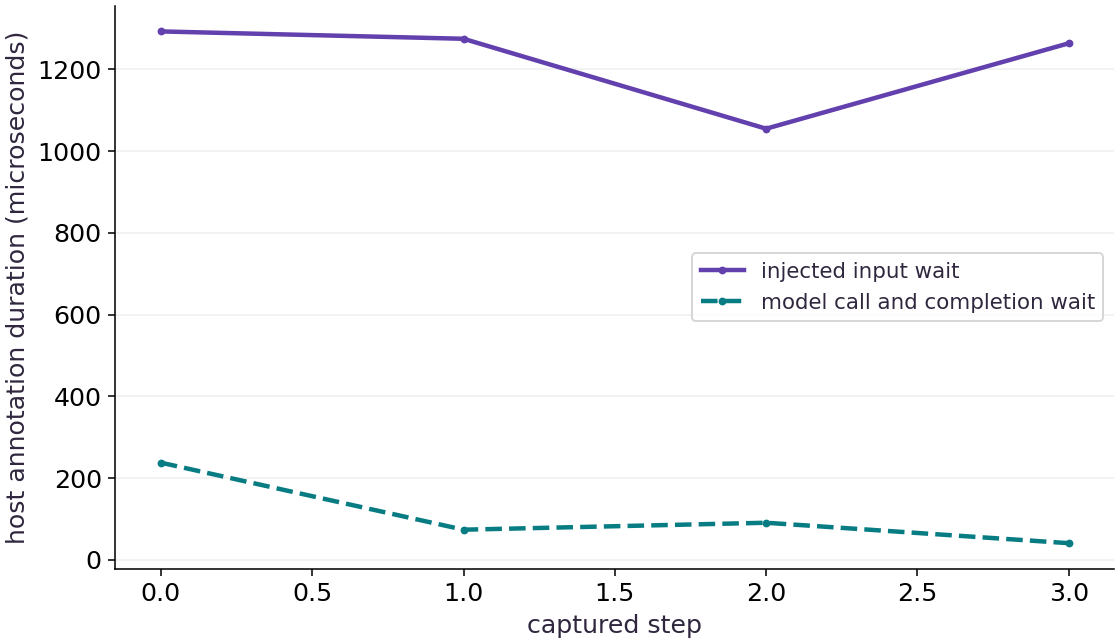

In [5]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal axis identifies the four captured steps. The vertical axis reports microseconds from actual trace events. The input-wait series contains a requested one-millisecond host sleep, so its duration should be interpreted around that scale with scheduler and profiler overhead; it is not a fixed measured constant.

The model-and-wait series covers dispatch through result readiness. Compare the numeric ticks and the recorded sample list to see which region takes longer in this run. Variation between steps can reflect scheduling or profiling overhead; it does not by itself demonstrate changing model work.

### Connect it to the computation

Both plotted series are child regions within a learner_step annotation. They do not include warmup and they are not two isolated accelerator kernels. The code verifies their temporal order and checks the model output independently before interpreting the trace.

The outer step also contains small amounts of other host work. Do not add the outer duration to these inner durations, or call the injected sleep a measured production data stall. Replace the sleep with a real input fetch to investigate an actual pipeline.

## Account for the enclosing step

Predict: What happens if you sum outer and inner durations as though they were independent work?

In [6]:
overhead=np.asarray(step_us)-np.asarray(input_us)-np.asarray(model_us)
assert np.all(overhead>=-2)
wrong=np.asarray(step_us)+np.asarray(input_us)+np.asarray(model_us)
assert np.all(wrong>=np.asarray(step_us))
print('Unattributed outer time, microseconds:',overhead.tolist())
print('Wrong double-counted totals:',wrong.tolist())

Unattributed outer time, microseconds: [19, 14, 7, 5]
Wrong double-counted totals: [3081, 2712, 2299, 2615]


Expected: The remainder is nonnegative within rounding; the double-counted totals exceed the step durations.

Outer and child intervals describe nested boundaries. The remainder is host/annotation work inside the step but outside its two children; it is not automatically device idle time.

## Your exercise

Convert every model interval to milliseconds and summarize its minimum, median and maximum. Keep the individual samples and explain why four observations cannot establish a tail-latency service guarantee.

In [7]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [8]:
model_ms=np.asarray(model_us)/1000
summary={'minimum_ms':float(model_ms.min()),'median_ms':float(np.median(model_ms)),'maximum_ms':float(model_ms.max())}
assert summary['minimum_ms']<=summary['median_ms']<=summary['maximum_ms']
np.testing.assert_allclose(model_ms*1000,model_us)
print(summary)

{'minimum_ms': 0.041, 'median_ms': 0.08249999999999999, 'maximum_ms': 0.238}


## Compute a union instead of summing overlap · Transfer

For hypothetical intervals [0,10], [2,7] and [8,12] microseconds, calculate their union duration and compare with their summed durations. Explain why this matters for nested host events.

Hint: Sort endpoints and merge intervals that intersect.

In [9]:
# Write your attempt here.

## Reference reasoning

A union describes time covered by any interval. A sum counts overlap repeatedly. Neither alone says which device was busy; lane and dependency information still matter.

In [10]:
def union_duration(intervals):
    total=0;left=right=None
    for start,end in sorted(intervals):
        if end<start:raise ValueError('negative interval')
        if right is None:left,right=start,end
        elif start<=right:right=max(right,end)
        else:total+=right-left;left,right=start,end
    return total+(0 if right is None else right-left)
assert union_duration([(0,10),(2,7),(8,12)])==12
assert sum(b-a for a,b in [(0,10),(2,7),(8,12)])==19
print('Hypothetical union: 12 microseconds; summed duration: 19.')

Hypothetical union: 12 microseconds; summed duration: 19.


## Checkpoint

A step annotation lasts longer than its model annotation. What can this alone establish?

1. The accelerator was idle for the entire difference.
2. The whole difference is input loading.
3. The step includes time outside the model region; inspect the other regions and lanes to explain it.

## Diagnose

If expected events are absent, verify that the trace scope surrounds execution, warmup is outside it, names match exactly, and the selected file belongs to the latest capture. If nested durations do not fit, inspect timestamps and thread IDs rather than adding unrelated lanes.

## Evidence

Keep the actual XPlane and Perfetto paths, named interval durations and nesting check, units and an interpretation separating injected input delay from completed computation.

## Carry forward

- Name trace regions for a concrete diagnostic question.
- Read units, threads and nesting before attributing time.
- Confirm trace-driven changes with an independent benchmark.

## Primary references

- [JAX profiling guide and XProf workflow](https://docs.jax.dev/en/latest/profiling.html)